# Regression Problem - GDP Prediction
This project aims to predict GDP based on COVID-19 statistics and economic indicators.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv(r"C:\Users\rotem\Desktop\Python\ECOM AI course\project II\Excel Files\Covid19_With_GDP_Values.csv", index_col=0)
df.head()

,Country/Region,Date,Province/State,Confirmed,Deaths,Recovered,GDP,Unemployment,CPI
0,Afghanistan,2021-01-01,0,52513.0,2201.0,41727.0,1.426650e+10,11.934,NaN
1,Afghanistan,2022-01-01,0,158107.0,7356.0,0.0,1.450216e+10,14.100,NaN
2,Albania,2021-01-01,0,58316.0,1181.0,33634.0,1.793057e+10,12.473,123.448662
3,Albania,2022-01-01,0,210224.0,3217.0,0.0,1.891638e+10,11.588,131.750835
4,Algeria,2021-01-01,0,99897.0,2762.0,67395.0,1.862654e+11,13.607,166.218895


# 1. Data Preparation: 
### 1.1 Removing meaningless columns
We'll drop- 'Province/State',
because most of its values are missing (NaN), and our analysis is at the country level, making it irrelevant.

In [3]:
df = df.drop(['Province/State'], axis=1)
df

,Country/Region,Date,Confirmed,Deaths,Recovered,GDP,Unemployment,CPI
0,Afghanistan,2021-01-01,52513.0,2201.0,41727.0,1.426650e+10,11.934,NaN
1,Afghanistan,2022-01-01,158107.0,7356.0,0.0,1.450216e+10,14.100,NaN
2,Albania,2021-01-01,58316.0,1181.0,33634.0,1.793057e+10,12.473,123.448662
3,Albania,2022-01-01,210224.0,3217.0,0.0,1.891638e+10,11.588,131.750835
4,Algeria,2021-01-01,99897.0,2762.0,67395.0,1.862654e+11,13.607,166.218895
...,...,...,...,...,...,...,...,...
335,West Bank and Gaza,2022-01-01,469748.0,4919.0,0.0,1.916550e+10,24.420,117.301113
336,Zambia,2021-01-01,20997.0,390.0,18773.0,2.209642e+10,5.195,299.818966
337,Zambia,2022-01-01,257948.0,3740.0,0.0,2.916378e+10,5.993,332.778677
338,Zimbabwe,2021-01-01,14084.0,369.0,11347.0,2.837124e+10,9.540,5411.002445


### 1.2. Data Aggregation
Since the dataset contains data for each country for both 2021 and 2022, we aggregated the data by country. For COVID-19 columns (Confirmed, Deaths, Recovered) we used sum since they represent cumulative counts. 

For economic indicators (GDP, Unemployment, CPI) we used mean since they represent a country's economic state, not cumulative values.

In [4]:
df_agg = df.groupby('Country/Region').agg({
    'Confirmed': 'sum',
    'Deaths': 'sum',
    'Recovered': 'sum',
    'GDP': 'mean',
    'Unemployment': 'mean',
    'CPI': 'mean'
}).reset_index()

df_agg

,Country/Region,Confirmed,Deaths,Recovered,GDP,Unemployment,CPI
0,Afghanistan,210620.0,9557.0,41727.0,1.438433e+10,13.0170,NaN
1,Albania,268540.0,4398.0,33634.0,1.842347e+10,12.0305,127.599748
2,Algeria,318715.0,9046.0,67395.0,2.059128e+11,13.0220,173.919413
3,Andorra,31857.0,224.0,7463.0,3.352643e+09,12.4370,181.619932
4,Angola,99966.0,2177.0,11146.0,8.545244e+10,15.2460,645.998608
...,...,...,...,...,...,...,...
165,Uzbekistan,276212.0,2099.0,75244.0,7.537072e+10,4.9400,375.337755
166,Vanuatu,8.0,1.0,1.0,9.863067e+08,4.9525,130.479616
167,West Bank and Gaza,608971.0,6337.0,118926.0,1.863725e+10,25.4050,115.185995
168,Zambia,278945.0,4130.0,18773.0,2.563010e+10,5.5940,316.298821


### 1.3. Checking for Missing Values
After aggregation, we check for missing values since some countries may have had missing data for one or both years, which could result in NaN values after the mean/sum operations.

In [5]:
print(df_agg.isnull().sum())
print("\n % NaN:")
print((df_agg.isnull().sum() / len(df_agg) * 100).round(2))

Country/Region    0
Confirmed         0
Deaths            0
Recovered         0
GDP               0
Unemployment      0
CPI               1
dtype: int64

 % NaN:
Country/Region    0.00
Confirmed         0.00
Deaths            0.00
Recovered         0.00
GDP               0.00
Unemployment      0.00
CPI               0.59
dtype: float64


###      Handling Missing Values
Only 1 row had a missing value in CPI (<1% of the data), so we'll simply droppe it.

In [6]:
df_agg = df_agg.dropna()
df_agg

,Country/Region,Confirmed,Deaths,Recovered,GDP,Unemployment,CPI
1,Albania,268540.0,4398.0,33634.0,1.842347e+10,12.0305,127.599748
2,Algeria,318715.0,9046.0,67395.0,2.059128e+11,13.0220,173.919413
3,Andorra,31857.0,224.0,7463.0,3.352643e+09,12.4370,181.619932
4,Angola,99966.0,2177.0,11146.0,8.545244e+10,15.2460,645.998608
5,Antigua and Barbuda,4442.0,124.0,148.0,1.734550e+09,14.6930,123.019852
...,...,...,...,...,...,...,...
165,Uzbekistan,276212.0,2099.0,75244.0,7.537072e+10,4.9400,375.337755
166,Vanuatu,8.0,1.0,1.0,9.863067e+08,4.9525,130.479616
167,West Bank and Gaza,608971.0,6337.0,118926.0,1.863725e+10,25.4050,115.185995
168,Zambia,278945.0,4130.0,18773.0,2.563010e+10,5.5940,316.298821


### 1.4. Checking for duplicated values


In [7]:
print(df_agg.duplicated().sum())


0


### 1.5 Log Transformation
We apply np.log1p to GDP, Confirmed, Deaths, and Recovered since these columns span very large ranges, which improves model performance.

In [8]:
df_agg = df_agg.set_index('Country/Region')

df_agg['GDP'] = np.log1p(df_agg['GDP'])
df_agg['Confirmed'] = np.log1p(df_agg['Confirmed'])
df_agg['Deaths'] = np.log1p(df_agg['Deaths'])
df_agg['Recovered'] = np.log1p(df_agg['Recovered'])

df_agg.head()

,Confirmed,Deaths,Recovered,GDP,Unemployment,CPI
Country/Region,,,,,,
Albania,12.500759,8.389133,10.423322,23.636891,12.0305,127.599748
Algeria,12.672056,9.110188,11.118341,26.050719,13.0220,173.919413
Andorra,10.369044,5.416100,8.917847,21.933015,12.4370,181.619932
Angola,11.512595,7.686162,9.318926,25.171226,15.2460,645.998608
Antigua and Barbuda,8.399085,4.828314,5.003946,21.274014,14.6930,123.019852


**Data Preparation Summary**

1. Dropped `Province/State` — mostly NaN and irrelevant to country-level analysis.
2. Aggregated data by country using `sum` for COVID columns and `mean` for economic indicators.
3. Dropped 1 row with a missing `CPI` value (<1% of data).
4. No duplicate rows were found.
5. Set `Country/Region` as index.
6. Applied `log1p` transformation to `GDP`, `Confirmed`, `Deaths`, and `Recovered` to compress large value ranges.

# 2. Data Exploration:
No we'll explore the relationships between features using a correlation heatmap and a pairplot to identify which features are most relevant to predicting GDP.

### 2.1 Pairplot
We visualize the relationships between all features using a pairplot.

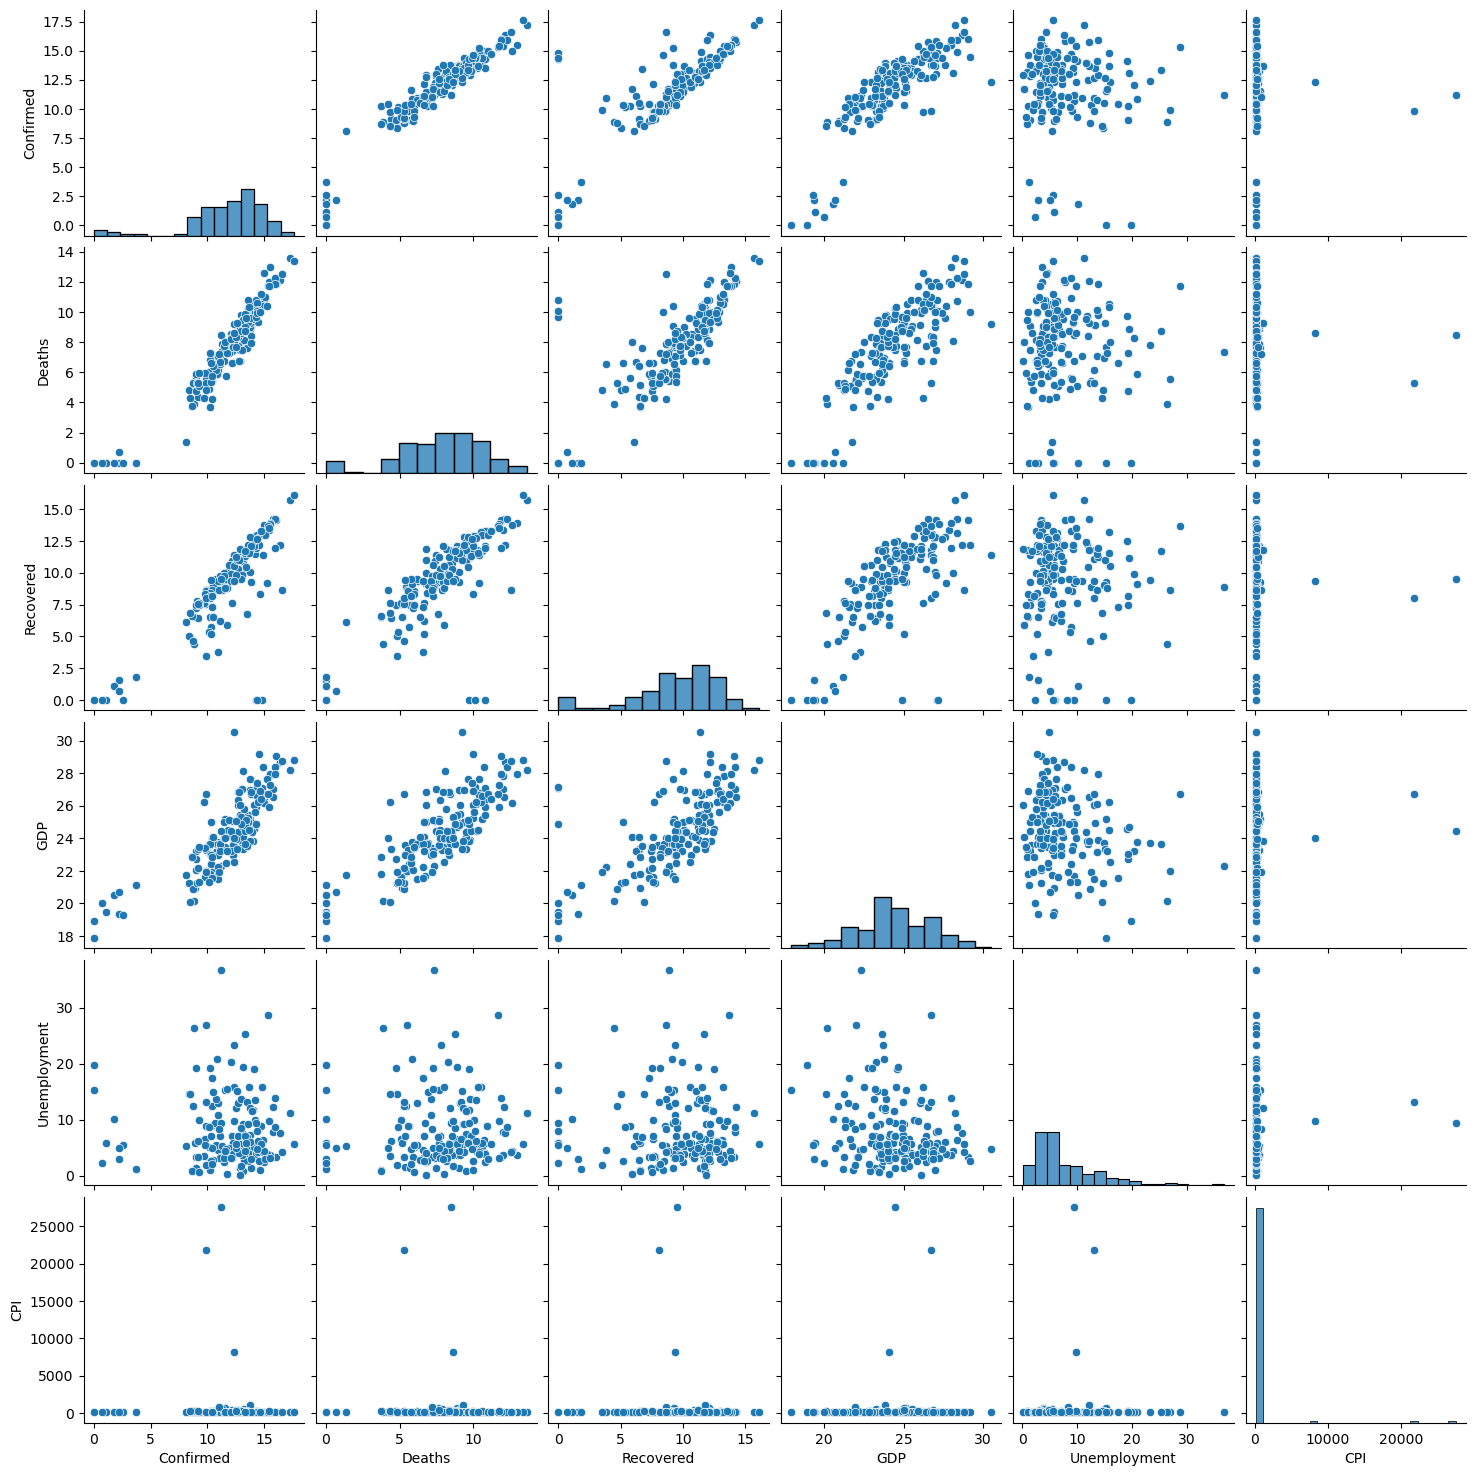

In [9]:
sns.pairplot(df_agg)
plt.show()

### 2.2 Correlation Heatmap
We visualize the correlations between all features and the target column (GDP) using a heatmap.

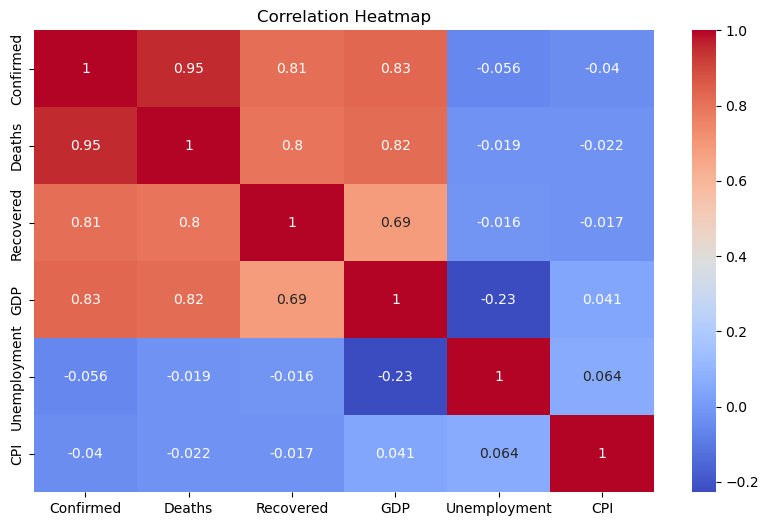

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df_agg.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### 2.3 Correlation Insights

**Strong correlation with GDP:**
- `Confirmed` (0.83) and `Deaths` (0.82) show strong positive correlation with GDP. This is likely because wealthier countries had better healthcare systems and testing capabilities, allowing them to detect and report more cases.
- `Recovered` (0.69) also shows a positive correlation, again reflecting better healthcare infrastructure in wealthier countries.

**Weak correlation with GDP:**
- `Unemployment` (-0.23) shows a weak negative correlation — higher unemployment slightly relates to lower GDP, which is economically logical.
- `CPI` (0.041) shows almost no correlation with GDP.

**Strong correlation between features:**
- `Confirmed` and `Deaths` (0.95) are strongly correlated with each other, which makes sense — more cases naturally lead to more deaths.
- `Confirmed` and `Recovered` (0.81) are also strongly correlated for the same reason.

**Model Selection Insights:**

The correlation analysis revealed strong linear relationships between the COVID features and GDP (Confirmed: 0.83, Deaths: 0.82, Recovered: 0.69), suggesting these are the most relevant features for prediction. However, high correlation between features themselves (Confirmed ↔ Deaths: 0.95) indicates multicollinearity, which suggests that Ridge Regression may outperform standard Linear Regression.

# 3. Model Training:

**Defining Features and Label**


In [11]:
X = df_agg.drop('GDP', axis=1)
y = df_agg['GDP']

**Feature Scaling - Standardization**


In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Train/Test Split**


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

### 3.1 Linear Regression with K-Fold Cross Validation
We train a basic Linear Regression model with K-Fold Cross Validation to evaluate its performance and avoid overfitting.

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

model_lr = LinearRegression()
scores = cross_val_score(model_lr, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
print("MSE scores:", -scores)
print("Mean MSE:", -scores.mean())

MSE scores: [2.49263088 0.84477622 1.38637557 1.09673209 1.39059609]
Mean MSE: 1.4422221692393908


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("\nCoefficients:", model_lr.coef_)

MAE: 1.1017674731988183
MSE: 1.973738256592033
RMSE: 1.4048979523766247

Coefficients: [ 0.89021988  1.18893009 -0.09267569 -0.47029139 -0.02169898]


**Beta Coefficients Interpretation**

The beta coefficients represent the weight each feature has on the predicted GDP (in log scale):

Confirmed → positive: countries with more cases tend to have higher GDP (better testing infrastructure) 
Deaths → positive: strongest predictor, highly correlated with confirmed cases
Recovered → near zero: low contribution to prediction
Unemployment → negative: higher unemployment = lower GDP
CPI → near zero: minimal impact on GDP prediction

**Linear Regression Results**

The model achieved an RMSE of 1.40 on a target range of 17.9–30.5 (~11% error) — a reasonable baseline. 

The most influential features were Deaths (1.19) and Confirmed (0.89), both positively correlated with GDP, while Unemployment (-0.47) had a negative effect as expected.

### 3.2 RidgeCV Regression
Since we detected multicollinearity between features (Confirmed ↔ Deaths: 0.95), we use Ridge Regression which penalizes large coefficients and handles multicollinearity better than standard Linear Regression. RidgeCV automatically finds the optimal alpha using cross validation.

In [16]:
from sklearn.linear_model import RidgeCV

ridge_model = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100, 1000], cv=5)
ridge_model.fit(X_train, y_train)

print("Optimal alpha:", ridge_model.alpha_)

Optimal alpha: 10.0


In [17]:
y_pred_ridge = ridge_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_ridge)
mse = mean_squared_error(y_test, y_pred_ridge)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("\nCoefficients:", ridge_model.coef_)

MAE: 1.061963239351557
MSE: 1.8538939220137838
RMSE: 1.3615777326373195

Coefficients: [ 0.87002263  0.97498281  0.08573176 -0.43522751 -0.01695971]


**RidgeCV Results**

RidgeCV found an optimal alpha of 10, achieving an RMSE of 1.36 — a slight improvement over Linear Regression. The small improvement confirms that multicollinearity exists but is not severe enough to make a significant difference.

### 3.3 LassoCV Regression
Lasso works similarly to Ridge but can shrink coefficients all the way to zero, effectively removing irrelevant features. This is useful since we saw that some features like CPI and Recovered had very low correlation with GDP.

In [18]:
from sklearn.linear_model import LassoCV

lasso_model = LassoCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5)
lasso_model.fit(X_train, y_train)

print("Optimal alpha:", lasso_model.alpha_)

Optimal alpha: 0.1


In [19]:
y_pred_lasso = lasso_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lasso)
mse = mean_squared_error(y_test, y_pred_lasso)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("\nCoefficients:", lasso_model.coef_)

MAE: 1.0671773834686913
MSE: 1.8622632990263333
RMSE: 1.3646476831132397

Coefficients: [ 0.82410916  1.06715347  0.         -0.37795682 -0.        ]


**LassoCV Results**

Lasso shrunk `Recovered` and `CPI` coefficients to zero, effectively removing them from the model. This confirms our earlier correlation analysis which showed these features had very low correlation with GDP. The RMSE of 1.36 is similar to Ridge, suggesting these features were indeed not contributing meaningful information.

### 3.4 Polynomial Regression
We test if a non-linear relationship fits the data better by adding polynomial features. We use cross validation to find the optimal degree.

In [20]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

degrees = [1,2, 3, 4, 5]
rmse_scores = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    y_pred = model.predict(X_test_poly)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_scores.append(rmse)
    print(f"Degree {degree} - RMSE: {rmse:.4f}")

Degree 1 - RMSE: 1.4049
Degree 2 - RMSE: 17.6261
Degree 3 - RMSE: 5781.1604
Degree 4 - RMSE: 2006773.3065
Degree 5 - RMSE: 7076.1197


**Polynomial Regression Results**

By testing degrees 1-5, we can clearly see that Degree 1 (linear) achieves the lowest RMSE (1.40), confirming that the relationship between features and GDP is linear. Higher degrees show severe overfitting with RMSE values reaching millions. Therefore, we select degree 1 as the optimal degree.

### 3.5 Model Comparison Plot

We visualize the RMSE of all models in a single plot to compare their performance.

In [21]:
results = {
    'MAE': [1.1018, 1.0620, 1.0672],
    'MSE': [1.9737, 1.8539, 1.8623],
    'RMSE': [1.4049, 1.3616, 1.3646]
}

plot_df = pd.DataFrame(results, index=['Linear', 'Ridge', 'Lasso'])
plot_df

,MAE,MSE,RMSE
Linear,1.1018,1.9737,1.4049
Ridge,1.0620,1.8539,1.3616
Lasso,1.0672,1.8623,1.3646


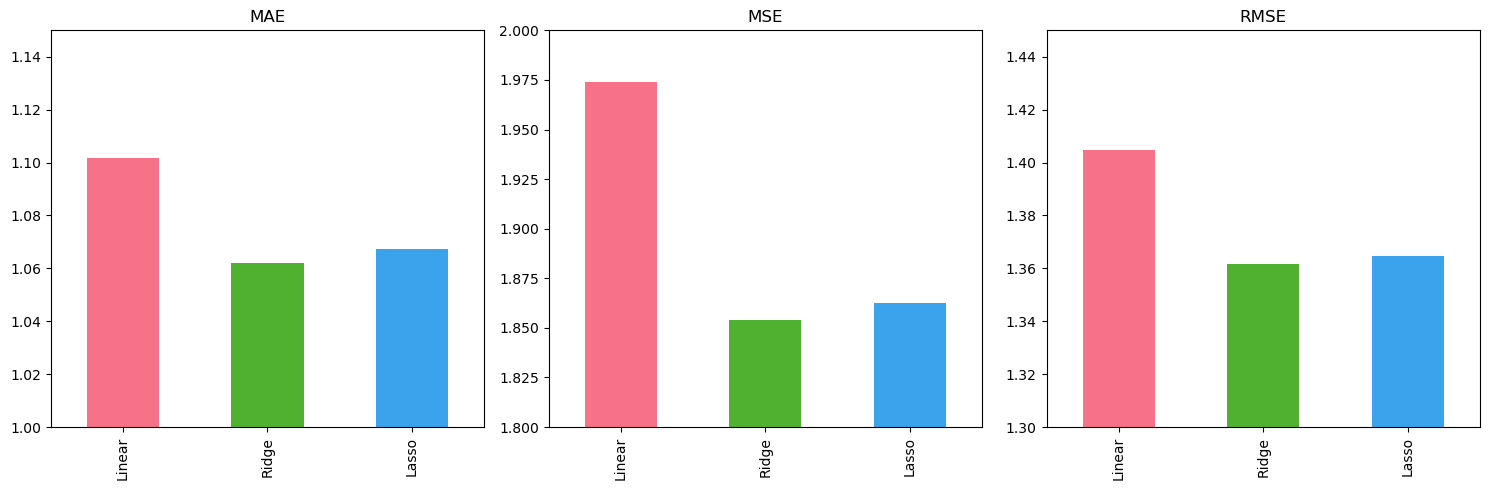

In [22]:
palette = sns.color_palette("husl", 3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_df["MAE"].plot(kind="bar", ax=axes[0], title="MAE", color=palette)
plot_df["MSE"].plot(kind="bar", ax=axes[1], title="MSE", color=palette)
plot_df["RMSE"].plot(kind="bar", ax=axes[2], title="RMSE", color=palette)

axes[0].set_ylim([1.0, 1.15])
axes[1].set_ylim([1.8, 2.0])
axes[2].set_ylim([1.3, 1.45])

plt.tight_layout()
plt.show()

**Model Comparison & Selection**

We compare all three models using MAE, MSE and RMSE. **Ridge Regression achieved the lowest RMSE (1.36)**, making it the best performing model. The differences are small, which is expected given the linear nature of the data.

## Training Final Model on Entire Dataset


In [23]:
X_scaled_full = scaler.fit_transform(X)

final_model = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100, 1000], cv=5)
final_model.fit(X_scaled_full, y)

print("Final model alpha:", final_model.alpha_)

Final model alpha: 10.0


We retrain the best model (Ridge) on the entire dataset to maximize the amount of data the model learns from before deployment. The optimal alpha remains 10, consistent with our earlier training, which confirms the stability of the model.

# 4. Exporting Final Model


In [26]:
import joblib

joblib.dump(final_model, 'ridge_model.joblib')
joblib.dump(scaler, 'scaler_gdp.joblib')

print("Model saved successfully!")

Model saved successfully!


# 5. Importing Final Model

In [28]:
loaded_model = joblib.load('ridge_model.joblib')
loaded_scaler = joblib.load('scaler_gdp.joblib')

print("Model loaded successfully!")
print("Alpha:", loaded_model.alpha_)

Model loaded successfully!
Alpha: 10.0


**And That's a Wrap on Regression**

We trained four models to predict GDP: Linear Regression, RidgeCV, LassoCV, and Polynomial Regression. 
**Ridge achieved the best performance** with RMSE of 1.36. The final model was trained on the entire dataset and exported to a joblib file.